In [5]:
%pip install pandas numpy matplotlib scikit-learn tensorflow

  Using cached numpy-2.4.2-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.17.0-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached protobuf-6.33.5-cp310-abi3-win_amd64.whl.metadata (593 bytes)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Usi

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] T

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# A single file has 20480 rows (1 second of data)
# We split it into smaller windows of 2048 points (0.1 seconds) to create more training samples
WINDOW_SIZE = 2048 
HEALTHY_DIR = './dataset/Healthy/'
FAULTY_DIR = './dataset/Faulty/'

def load_and_chunk_data(directory, label):
    data_windows = []
    labels = []
    
    if not os.path.exists(directory):
        print(f"Directory {directory} not found")
        return np.array([]), np.array([])

    for filename in os.listdir(directory):
        filepath = os.path.join(directory, filename)
        
        try:
            df = pd.read_csv(filepath, sep='\t', header=None)
            bearing_1_data = df.iloc[:, 0].values
            
            for i in range(0, len(bearing_1_data) - WINDOW_SIZE, WINDOW_SIZE):
                window = bearing_1_data[i : i + WINDOW_SIZE]
                data_windows.append(window)
                labels.append(label)
        except Exception as e:
            pass
            
    return np.array(data_windows), np.array(labels)

print("Loading Healthy Data")
healthy_X, healthy_y = load_and_chunk_data(HEALTHY_DIR, label=0) # 0 = Healthy

print("Loading Faulty Data")
faulty_X, faulty_y = load_and_chunk_data(FAULTY_DIR, label=1) # 1 = Faulty

if len(healthy_X) > 0 and len(faulty_X) > 0:
    X = np.vstack((healthy_X, faulty_X))
    y = np.hstack((healthy_y, faulty_y))

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train).reshape(-1, WINDOW_SIZE, 1)
    X_test_scaled = scaler.transform(X_test).reshape(-1, WINDOW_SIZE, 1)

    print(f"Training Samples: {X_train_scaled.shape[0]}")
    print(f"Testing Samples: {X_test_scaled.shape[0]}")
    print(f"Shape of sample: {X_train_scaled.shape[1:]}")
else:
    print("No data loaded")

Loading Healthy Data
Loading Faulty Data
Training Samples: 4320
Testing Samples: 1080
Shape of sample: (2048, 1)


c:\Users\susti\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 1985, 64)       │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1985, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 496, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 465, 128)       │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 465, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 116, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 101, 256)       │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 101, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 25, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     1,638,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,464,449 (9.40 MB)

 Trainable params: 2,463,553 (9.40 MB)

 Non-trainable params: 896 (3.50 KB)

Training Model
Epoch 1/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 20s 259ms/step - accuracy: 0.9787 - loss: 0.0876 - val_accuracy: 0.7843 - val_loss: 2.0544
Epoch 2/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 261ms/step - accuracy: 0.9981 - loss: 0.0061 - val_accuracy: 0.7889 - val_loss: 1.9406
Epoch 3/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 17s 256ms/step - accuracy: 0.9977 - loss: 0.0095 - val_accuracy: 0.6037 - val_loss: 9.5008
Epoch 4/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 260ms/step - accuracy: 0.9998 - loss: 0.0016 - val_accuracy: 0.7926 - val_loss: 5.9800
Epoch 5/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 259ms/step - accuracy: 1.0000 - loss: 8.5389e-06 - val_accuracy: 0.8444 - val_loss: 2.9713
Epoch 6/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 17s 254ms/step - accuracy: 0.9961 - loss: 0.0153 - val_accuracy: 0.9926 - val_loss: 0.0380
Epoch 7/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 17s 252ms/step - accuracy: 0.9995 - loss: 0.0110 - val_accuracy: 0.9991 - val_loss: 0.0051
Epoch 8/50
68/68 ━━━━━━━━━━━━━━━━━━━━ 17s 255ms/step - accuracy: 1.0000 - loss

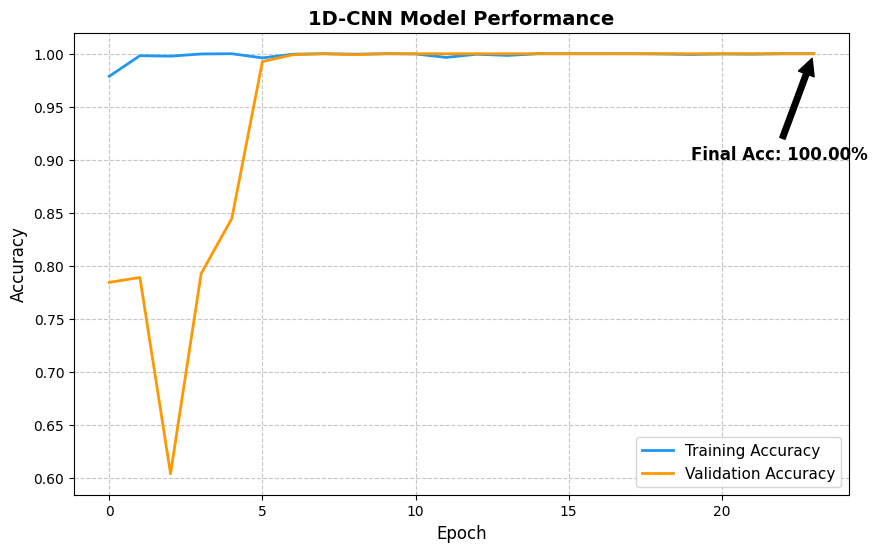


Final Model Accuracy on Test Data: 100.00%


In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

model = Sequential([
    # Feature Extraction
    Conv1D(filters=64, kernel_size=64, activation='relu', input_shape=(X_train_scaled.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=4),
    
    # Deep Feature Extraction
    Conv1D(filters=128, kernel_size=32, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=4),
    
    # Granular Pattern Recognition
    Conv1D(filters=256, kernel_size=16, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=4),
    
    Flatten(),
    
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.4),
    
    Dense(1, activation='sigmoid')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Training Model")
history = model.fit(X_train_scaled, y_train, 
                    epochs=50, 
                    batch_size=64, 
                    validation_data=(X_test_scaled, y_test),
                    callbacks=[early_stop])

plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, color='#2196F3')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='#FF9800')
plt.title('1D-CNN Model Performance', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

final_acc = history.history['val_accuracy'][-1] * 100
plt.annotate(f'Final Acc: {final_acc:.2f}%', 
             xy=(len(history.history['val_accuracy'])-1, history.history['val_accuracy'][-1]),
             xytext=(len(history.history['val_accuracy'])-5, history.history['val_accuracy'][-1] - 0.1),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12, fontweight='bold')

plt.show()

# Print Final Evaluation
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nFinal Model Accuracy on Test Data: {test_acc * 100:.2f}%")

In [12]:
import os
import tensorflow as tf

print("Converting model to TinyML")

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_filename = "edge_fault_detector.tflite"
with open(tflite_filename, "wb") as f:
    f.write(tflite_model)

model.save("temp_original_model.keras")
keras_size = os.path.getsize("temp_original_model.keras") / (1024 * 1024)
tflite_size = os.path.getsize(tflite_filename) / (1024 * 1024)

print(f"Original Model Size: {keras_size:.2f} MB")
print(f"TinyML Model Size:   {tflite_size:.2f} MB")
print(f"Total Size Reduction: {(1 - tflite_size/keras_size)*100:.2f}%")

Converting model to TinyML
INFO:tensorflow:Assets written to: C:\Users\susti\AppData\Local\Temp\tmpgh1m510e\assets


INFO:tensorflow:Assets written to: C:\Users\susti\AppData\Local\Temp\tmpgh1m510e\assets


Saved artifact at 'C:\Users\susti\AppData\Local\Temp\tmpgh1m510e'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 2048, 1), dtype=tf.float32, name='keras_tensor_16')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2482834088464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2482834085968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2482834089040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2482834083280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2482834086160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2482834085776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2482834090768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2482834088848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2482855504080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2482855508112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  248283